In [5]:
!pip install tensorflow opencv-python matplotlib seaborn pandas numpy

Defaulting to user installation because normal site-packages is not writeable


In [1]:
!pip install --upgrade numpy pandas --user

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.7 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.7 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.7 MB 1.6 MB/s eta 0:00:05
   ------------- -------------------------- 3.4/9.7 MB 1.7 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.7 MB 1.7 MB/s eta 0:00:04
   ----------------- ---------------------- 4.2/9.7 MB 1.7 MB/s eta 0:00:04
   ------------------- -------------------- 4.7/9.7 MB 1.8 MB/s eta 0:00:03
   --------------------- ------------------ 5.2/9.7 MB 1.8 MB/s eta 0:00:03
   ------------------------ --------------- 6.0/9.7 MB 1.9 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.7 MB 1.9 MB/s eta 0:00:02
   -----------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.32.1 which is incompatible.


In [3]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd

Total Diseases Found: 3
Categories: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


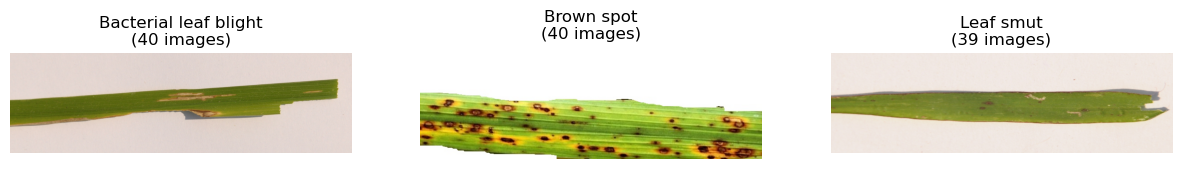

In [2]:
dataset_path = r'Rice_Data' 

import os
import matplotlib.pyplot as plt
import cv2

# Path sariyaa irukkannu check panna
classes = sorted(os.listdir(dataset_path))
print(f"Total Diseases Found: {len(classes)}")
print(f"Categories: {classes}")

# Visualize sample images
plt.figure(figsize=(15, 5))
for i, category in enumerate(classes):
    folder_path = os.path.join(dataset_path, category)
    # Folder-kulla images irukkannu check pannurom
    img_list = os.listdir(folder_path)
    if len(img_list) > 0:
        img_name = img_list[0]
        img_path = os.path.join(folder_path, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"{category}\n({len(img_list)} images)")
        plt.axis('off')
plt.show()

In [3]:
# Image size standardisation (224x224 for MobileNet)
IMG_SIZE = (224, 224)
BATCH_SIZE = 8 # Dataset chinna size, so small batch is better

train_datagen = ImageDataGenerator(
    rescale=1./255,            # Pixel values normalization (0-1)
    rotation_range=40,         # Rotation helps model see spots from any angle
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,            # Zooming picks up fine details of smut/spots
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2       # 24 images testing-ku, 96 images training-ku
)

train_gen = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


In [4]:
# Pre-trained base model (Weights from ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze weights initially

# Adding custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # To prevent memorizing/overfitting
outputs = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

optimizer = AdamW(learning_rate=0.0001, weight_decay=1e-4)

model.compile(
    optimizer=optimizer, 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

print("Model Architecture Ready with AdamW Optimizer!")

Model Architecture Ready with AdamW Optimizer!


In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=8, 
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=4, 
    min_lr=1e-6
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8646 - loss: 0.3510 - val_accuracy: 0.8696 - val_loss: 0.2982 - learning_rate: 1.0000e-06
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8542 - loss: 0.3945 - val_accuracy: 0.8696 - val_loss: 0.3338 - learning_rate: 1.0000e-06
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8646 - loss: 0.4089 - val_accuracy: 0.9130 - val_loss: 0.2188 - learning_rate: 1.0000e-06
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8542 - loss: 0.3965 - val_accuracy: 0.9565 - val_loss: 0.2294 - learning_rate: 1.0000e-06
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8125 - loss: 0.4321 - val_accuracy: 0.9130 - val_loss: 0.2451 - learning_rate: 1.0000e-06
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8750 - loss: 0.4404 - val_accuracy: 0.9565 - val_loss: 0.2335 - learning_rate: 1.0000e-06
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7812 - loss:

In [8]:

print("Evaluating model on validation data...")

val_loss, val_accuracy = model.evaluate(val_gen)

print("-" * 30)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_accuracy * 100:.4f}%")
print("-" * 30)

Evaluating model on validation data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 897ms/step - accuracy: 0.9130 - loss: 0.3056
------------------------------
Final Validation Loss: 0.3056
Final Validation Accuracy: 91.3043%
------------------------------


3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step 


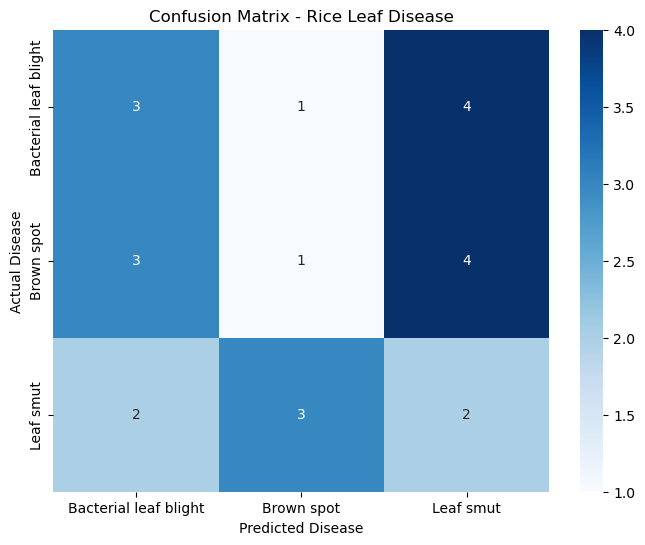


Detailed Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.38      0.38      0.38         8
           Brown spot       0.20      0.12      0.15         8
            Leaf smut       0.20      0.29      0.24         7

             accuracy                           0.26        23
            macro avg       0.26      0.26      0.25        23
         weighted avg       0.26      0.26      0.26        23



In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Predictions edukkurom
Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)

# Confusion Matrix create panrom
cm = confusion_matrix(val_gen.classes, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Rice Leaf Disease')
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(val_gen.classes, y_pred, target_names=classes))

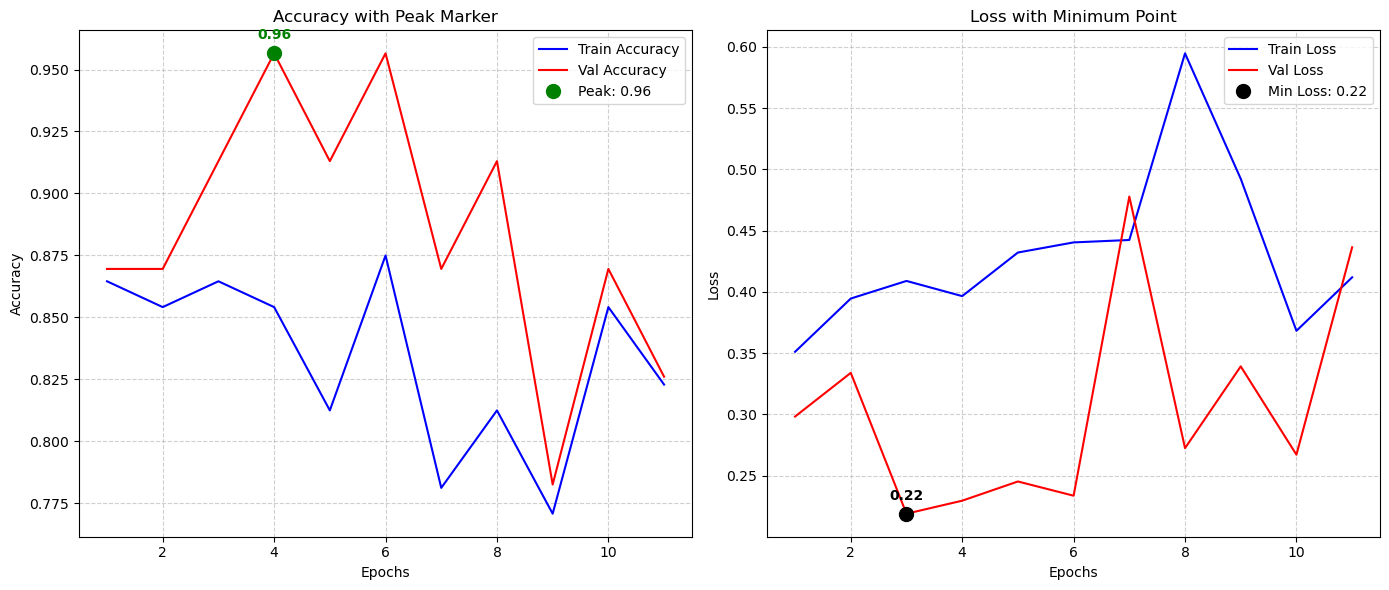

In [12]:
import numpy as np

plt.figure(figsize=(14, 6))

# --- 1. Accuracy Plot ---
plt.subplot(1, 2, 1)
epochs = range(1, len(history.history['accuracy']) + 1)
val_acc = history.history['val_accuracy']

# Normal lines
plt.plot(epochs, history.history['accuracy'], 'b-', label='Train Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Val Accuracy')

# Finding the Peak (Best Point)
best_epoch = np.argmax(val_acc)
best_acc = val_acc[best_epoch]

# Plotting the "Dot" (Marker)
plt.plot(best_epoch + 1, best_acc, 'go', markersize=10, label=f'Peak: {best_acc:.2f}')
plt.annotate(f'{best_acc:.2f}', (best_epoch + 1, best_acc), textcoords="offset points", xytext=(0,10), ha='center', color='green', weight='bold')

plt.title('Accuracy with Peak Marker')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- 2. Loss Plot ---
plt.subplot(1, 2, 2)
val_loss = history.history['val_loss']

# Normal lines
plt.plot(epochs, history.history['loss'], 'b-', label='Train Loss')
plt.plot(epochs, val_loss, 'r-', label='Val Loss')

# Finding the Lowest Point (Best Loss)
min_loss_epoch = np.argmin(val_loss)
min_loss = val_loss[min_loss_epoch]

# Plotting the "Dot" (Marker)
plt.plot(min_loss_epoch + 1, min_loss, 'ko', markersize=10, label=f'Min Loss: {min_loss:.2f}')
plt.annotate(f'{min_loss:.2f}', (min_loss_epoch + 1, min_loss), textcoords="offset points", xytext=(0,10), ha='center', color='black', weight='bold')

plt.title('Loss with Minimum Point')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [13]:
model.save('rice_leaf_disease_final.keras')
print("Professional Model saved successfully!")

Professional Model saved successfully!
